# 5. Final Visualisation Portfolio
## Southeast Asian Daily Weather Patterns (2000–2024)

This notebook produces the remaining visualisations required by the plan and assembles the complete output portfolio. Charts already generated in notebooks 02–04 are referenced here for completeness.

**New charts produced here:**
- Country comparison radar chart (multi-variable climate profile per country)
- Combined anomaly summary dashboard
- Final output index

**All 10 chart types from the execution plan:**

| # | Type | Status | File |
|---|---|---|---|
| 1 | Temperature trend lines | nb02 | `eda_01_temp_trends.png` |
| 2 | Decade-wise boxplots | nb02 | `eda_02_decade_boxplots.png` |
| 3 | Monthly temperature heatmap | nb02 | `eda_08_heatmap_tmax_all_countries.png` |
| 4 | Precipitation frequency histogram | nb02 | `eda_05_prcp_histogram.png` |
| 5 | Anomaly timeline | nb03 | `anom_02_zscore_timeline_vietnam.png` |
| 6 | Anomaly frequency trend | nb03 | `anom_01_zscore_frequency_trend.png` |
| 7 | Station map | nb02 | `eda_09_station_map.png` |
| 8 | Correlation heatmap | nb02 | `eda_11_correlation_heatmap.png` |
| 9 | Seasonal decomposition | nb04 | `reg_05/06/07_seasonal_decomp_*.png` |
| 10 | Country comparison radar chart | ⬅ **this notebook** | `viz_01_radar_chart.png` |

## Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, percentile_approx
from pyspark.sql import Window
from pyspark.sql.functions import stddev, abs as spark_abs
import pyspark.sql.functions as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import os, glob

OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

COUNTRIES_MAIN = ['Vietnam', 'Thailand', 'Philippines', 'Indonesia', 'Malaysia']
COUNTRY_COLORS = {
    'Vietnam': '#e63946', 'Thailand': '#2a9d8f', 'Philippines': '#e9c46a',
    'Indonesia': '#f4a261', 'Malaysia': '#457b9d', 'Myanmar': '#a8dadc',
    'Laos': '#6d6875', 'Brunei': '#b5838d', 'Singapore': '#e76f51', 'Cambodia': '#264653',
}

spark = SparkSession.builder \
    .appName('GHCN-SEA-Visualisation') \
    .config('spark.driver.memory', '8g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.shuffle.partitions', '100') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/sea_weather_2000_2024.parquet')
df.cache()
print(f"Loaded: {df.count():,} rows")

Loaded: 1,011,376 rows


---
## Chart 10: Country Comparison Radar Chart

Multi-variable climate profile for each country normalised to [0, 1] so all axes are comparable. Variables:
- avg_TMAX, avg_TMIN, avg_PRCP, TEMP_RANGE, heatwave_rate (Z-score > 2.5), extreme_rain_rate (PRCP > 95th pct)

In [2]:
# Build per-country climate profile 
# Compute 95th-percentile PRCP threshold per station-month first 
p95_stats = df.filter(col('PRCP').isNotNull())     .groupBy('STATION_ID', 'MONTH')     .agg(percentile_approx('PRCP', 0.95).alias('PRCP_P95'))

# Enrich df with Z-score and PRCP threshold in one pass, then aggregate in one groupBy
w = Window.partitionBy('STATION_ID', 'MONTH')
df_enriched = df     .withColumn('TMAX_MEAN',   avg('TMAX').over(w))     .withColumn('TMAX_STD',    stddev('TMAX').over(w))     .withColumn('TMAX_ZSCORE', (col('TMAX') - col('TMAX_MEAN')) / col('TMAX_STD'))     .join(p95_stats, on=['STATION_ID', 'MONTH'], how='left')

# Single groupBy: base stats + heatwave % + extreme rain % in one Spark job
profile_spark = df_enriched.groupBy('COUNTRY').agg(
    avg('TMAX').alias('avg_TMAX'),
    avg('TMIN').alias('avg_TMIN'),
    avg('PRCP').alias('avg_PRCP'),
    avg('TEMP_RANGE').alias('avg_TEMP_RANGE'),
    count('*').alias('n_obs'),
    (count(when(col('TMAX_ZSCORE') > 2.5, 1)) / count('*') * 100).alias('heatwave_pct'),
    (count(when(col('PRCP').isNotNull() & (col('PRCP') > col('PRCP_P95')), 1)) /
     count(when(col('PRCP').isNotNull(), 1)) * 100).alias('extreme_rain_pct'),
)

profile = profile_spark.filter(col('COUNTRY').isin(COUNTRIES_MAIN))     .toPandas()     .sort_values('COUNTRY')

print("Climate profile per country:")
print(profile.set_index('COUNTRY')[['avg_TMAX','avg_TMIN','avg_PRCP','avg_TEMP_RANGE',
                                      'heatwave_pct','extreme_rain_pct']].round(3).to_string())

Climate profile per country:
             avg_TMAX  avg_TMIN  avg_PRCP  avg_TEMP_RANGE  heatwave_pct  extreme_rain_pct
COUNTRY                                                                                  
Indonesia      31.729    23.401     3.923           8.328         0.356             3.098
Malaysia       32.009    23.861     9.472           8.148         0.235             4.740
Philippines    31.050    23.178    11.050           7.872         0.235             4.750
Thailand       33.272    23.226     6.866          10.046         0.213             4.781
Vietnam        29.360    22.188     4.011           7.172         0.330             4.691


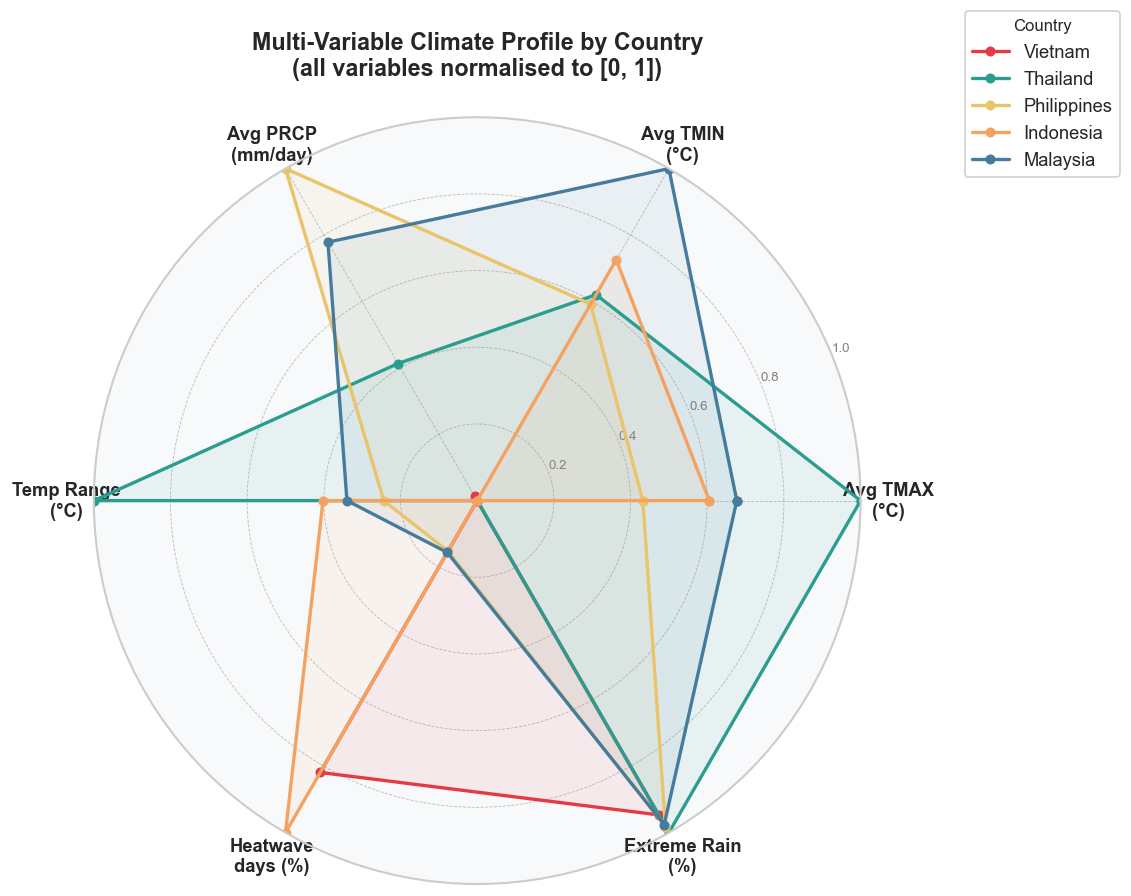

Radar chart saved


In [3]:
# Radar / spider chart 
RADAR_VARS = ['avg_TMAX', 'avg_TMIN', 'avg_PRCP', 'avg_TEMP_RANGE',
              'heatwave_pct', 'extreme_rain_pct']
RADAR_LABELS = ['Avg TMAX\n(°C)', 'Avg TMIN\n(°C)', 'Avg PRCP\n(mm/day)',
                'Temp Range\n(°C)', 'Heatwave\ndays (%)', 'Extreme Rain\n(%)']

# Min-max normalise each variable to [0, 1]
radar_norm = profile[['COUNTRY'] + RADAR_VARS].set_index('COUNTRY').copy()
for col_name in RADAR_VARS:
    mn, mx = radar_norm[col_name].min(), radar_norm[col_name].max()
    radar_norm[col_name] = (radar_norm[col_name] - mn) / (mx - mn) if mx > mn else 0.0

N = len(RADAR_VARS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

for country in COUNTRIES_MAIN:
    values = radar_norm.loc[country, RADAR_VARS].tolist()
    values += values[:1]
    color = COUNTRY_COLORS[country]
    ax.plot(angles, values, 'o-', color=color, linewidth=2, markersize=5, label=country)
    ax.fill(angles, values, alpha=0.08, color=color)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=11, fontweight='bold')
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='grey')
ax.set_ylim(0, 1)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11,
          framealpha=0.9, title='Country', title_fontsize=10)
ax.set_title('Multi-Variable Climate Profile by Country\n'
             '(all variables normalised to [0, 1])',
             fontsize=14, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz_01_radar_chart.png', bbox_inches='tight')
plt.show()
print("Radar chart saved")

---
## Bonus: Combined Anomaly Summary Dashboard

A single 2×3 panel figure summarising all three anomaly detection methods — suitable for the report's anomaly section.

In [4]:
# Compute all anomaly counts in one pass 
# Z-score heatwaves per year (all countries)
w_sm = Window.partitionBy('STATION_ID', 'MONTH')
df_z2 = df.withColumn('TMAX_MEAN', avg('TMAX').over(w_sm)) \
          .withColumn('TMAX_STD',  stddev('TMAX').over(w_sm)) \
          .withColumn('ZSCORE', (col('TMAX') - col('TMAX_MEAN')) / col('TMAX_STD'))

zscore_yearly = df_z2.groupBy('COUNTRY', 'YEAR').agg(
    count(when(col('ZSCORE') > 2.5, 1)).alias('heatwave_days'),
    count(when(col('ZSCORE') < -2.5, 1)).alias('cold_snap_days'),
    count('*').alias('total_obs'),
).toPandas()

# IQR extreme rain per year
p95 = df.filter(col('PRCP').isNotNull()) \
    .groupBy('STATION_ID', 'MONTH') \
    .agg(percentile_approx('PRCP', 0.95).alias('P95'))

rain_yearly = df.filter(col('PRCP').isNotNull()) \
    .join(p95, on=['STATION_ID', 'MONTH'], how='left') \
    .groupBy('COUNTRY', 'YEAR') \
    .agg(count(when(col('PRCP') > col('P95'), 1)).alias('extreme_rain_days')) \
    .toPandas()

# Merge and sum across countries
hw_total  = zscore_yearly.groupby('YEAR')['heatwave_days'].sum().reset_index()
cs_total  = zscore_yearly.groupby('YEAR')['cold_snap_days'].sum().reset_index()
er_total  = rain_yearly.groupby('YEAR')['extreme_rain_days'].sum().reset_index()

print("Anomaly aggregations complete")

Anomaly aggregations complete
